# Plot Results from tdinf Boson Star Analysis

This notebook plots the posterior samples from your NR boson star binary analysis.

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import seaborn as sns
import h5py
import emcee
import arviz as az

# Styling
sns.set_style("whitegrid")
sns.set_palette("colorblind")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

## Load Results

In [32]:
# Load the postprocessed data (physical parameters)
df = pd.read_csv('output/test_results.dat', sep=' ')

print(f"Number of samples: {len(df)}")
print(f"Number of parameters: {len(df.columns)}")
print(f"\nAvailable parameters:")
for i, col in enumerate(df.columns[:15]):
    print(f"  {col}")
print(f"  ... and {len(df.columns) - 15} more" if len(df.columns) > 15 else "")

Number of samples: 2560
Number of parameters: 31

Available parameters:
  right_ascension
  declination
  polarization
  geocenter_time
  total_mass
  mass_ratio
  luminosity_distance
  inclination
  phase
  spin1_x
  spin1_y
  spin1_z
  spin2_x
  spin2_y
  spin2_z
  ... and 16 more


## Load Reference Parameters (Injection Truth)

In [33]:
# Load injected/reference parameters from injection metadata
ref_metadata = pd.read_csv('../data/injection_metadata.csv').iloc[0]

# For parameter recovery, also check reference_parameters if it exists
try:
    ref_params = pd.read_csv('../data/reference_parameters.csv').iloc[0]
except:
    ref_params = ref_metadata

print("=" * 50)
print("INJECTED PARAMETERS")
print("=" * 50)
print(f"Total mass:          {ref_params.get('mass', ref_params.get('total_mass', 'N/A')):.2f} M☉")
print(f"Mass ratio:          {ref_params.get('mass_ratio', 'N/A'):.3f}" if 'mass_ratio' in ref_params else "Not in metadata")
print(f"Luminosity distance: {ref_params.get('luminosity_distance', 'N/A'):.1f} Mpc")
print(f"Inclination:         {ref_params.get('inclination', 'N/A'):.4f} rad")
print(f"Sky position:        RA={ref_params.get('ra', 'N/A'):.3f}, Dec={ref_params.get('dec', 'N/A'):.3f}")
print(f"Reference freq:      {ref_params.get('f_ref', 'N/A'):.2f} Hz")
print("=" * 50)

INJECTED PARAMETERS
Total mass:          71.50 M☉
Mass ratio:          1.000
Luminosity distance: 175.0 Mpc
Inclination:         0.7800 rad
Sky position:        RA=2.333, Dec=0.190
Reference freq:      0.00 Hz


## Create DataFrame with Parameter Names

In [34]:
# Parameter names - use the physical parameters from postprocessed data
param_names = ['total_mass', 'mass_ratio', 'luminosity_distance', 'inclination', 'phase']

# Filter to only parameters that exist in dataframe
param_names = [p for p in param_names if p in df.columns]

print(f"Sampled parameters to analyze: {param_names}")
print(f"Total parameters in posterior: {len(df.columns)}")
print(f"\nFirst few samples:")
print(df[param_names].head())

Sampled parameters to analyze: ['total_mass', 'mass_ratio', 'luminosity_distance', 'inclination', 'phase']
Total parameters in posterior: 31

First few samples:
   total_mass  mass_ratio  luminosity_distance  inclination     phase
0   71.780107    0.810741           424.092009     2.705900 -1.647968
1   74.893735    0.997862           468.231224     0.702025 -1.940532
2   71.488215    0.803418           478.120891     2.858126  1.158753
3   71.373104    0.837900           458.546072     2.713981  1.142735
4   71.446008    0.802004           498.659039     3.048542  1.108129


## Basic Statistics

In [35]:
print("\n" + "=" * 60)
print("POSTERIOR STATISTICS")
print("=" * 60)
stats = df[param_names].describe()
print(stats.to_string())
print("=" * 60)


POSTERIOR STATISTICS
        total_mass   mass_ratio  luminosity_distance  inclination        phase
count  2560.000000  2560.000000          2560.000000  2560.000000  2560.000000
mean     71.614020     0.817742           469.304887     2.770431     0.569162
std       0.628827     0.041580            25.992221     0.427718     1.225956
min      71.240264     0.800003           294.883335     0.225910    -2.089558
25%      71.437563     0.802349           457.688400     2.749791     1.092633
50%      71.465498     0.805717           473.722963     2.850579     1.133299
75%      71.489673     0.812694           486.440998     2.949924     1.154239
max      74.942006     0.999693           524.781611     3.136226     1.458839


## Walker Chains (Convergence Check)

In [36]:
# Load convergence diagnostics from raw HDF5
backend_file = 'output/test_results.h5'
reader = emcee.backends.HDFBackend(backend_file, read_only=True)

# Derive walkers and dimensionality from the stored chain shape
chain = reader.get_chain(flat=False)
try:
    niter, nwalkers, ndim = chain.shape
except Exception:
    # Fallback in case backend returns a view without full shape
    chain = reader.get_chain()
    niter, nwalkers, ndim = chain.shape

print("\n" + "=" * 60)
print("CONVERGENCE DIAGNOSTICS")
print("=" * 60)
print(f"Total iterations: {reader.iteration}")
print(f"Number of walkers: {nwalkers}")
print(f"Number of parameters: {ndim}")

try:
    tau = reader.get_autocorr_time(tol=0)
    print(f"\nAutocorrelation times (per parameter):")
    for i, t in enumerate(tau):
        print(f"  Parameter {i}: {t:.1f} steps")
    print(f"  Mean: {tau.mean():.1f} steps, Max: {tau.max():.1f} steps")
    
    convergence_ratio = reader.iteration / tau.max()
    print(f"\nConvergence check: nsteps/max(tau) = {convergence_ratio:.1f}x")
    print(f"  (Should be >> 100 for good convergence)")
    
    if convergence_ratio > 100:
        print("  ✓ CONVERGED")
    else:
        print("  ⚠ Consider increasing nsteps")
except Exception as e:
    print(f"Could not compute autocorrelation time: {e}")

print("=" * 60)


CONVERGENCE DIAGNOSTICS
Total iterations: 15000
Number of walkers: 64
Number of parameters: 6

Autocorrelation times (per parameter):
  Parameter 0: 547.2 steps
  Parameter 1: 589.1 steps
  Parameter 2: 756.2 steps
  Parameter 3: 839.1 steps
  Parameter 4: 530.2 steps
  Parameter 5: 567.0 steps
  Mean: 638.1 steps, Max: 839.1 steps

Convergence check: nsteps/max(tau) = 17.9x
  (Should be >> 100 for good convergence)
  ⚠ Consider increasing nsteps


## 1D Posterior Distributions

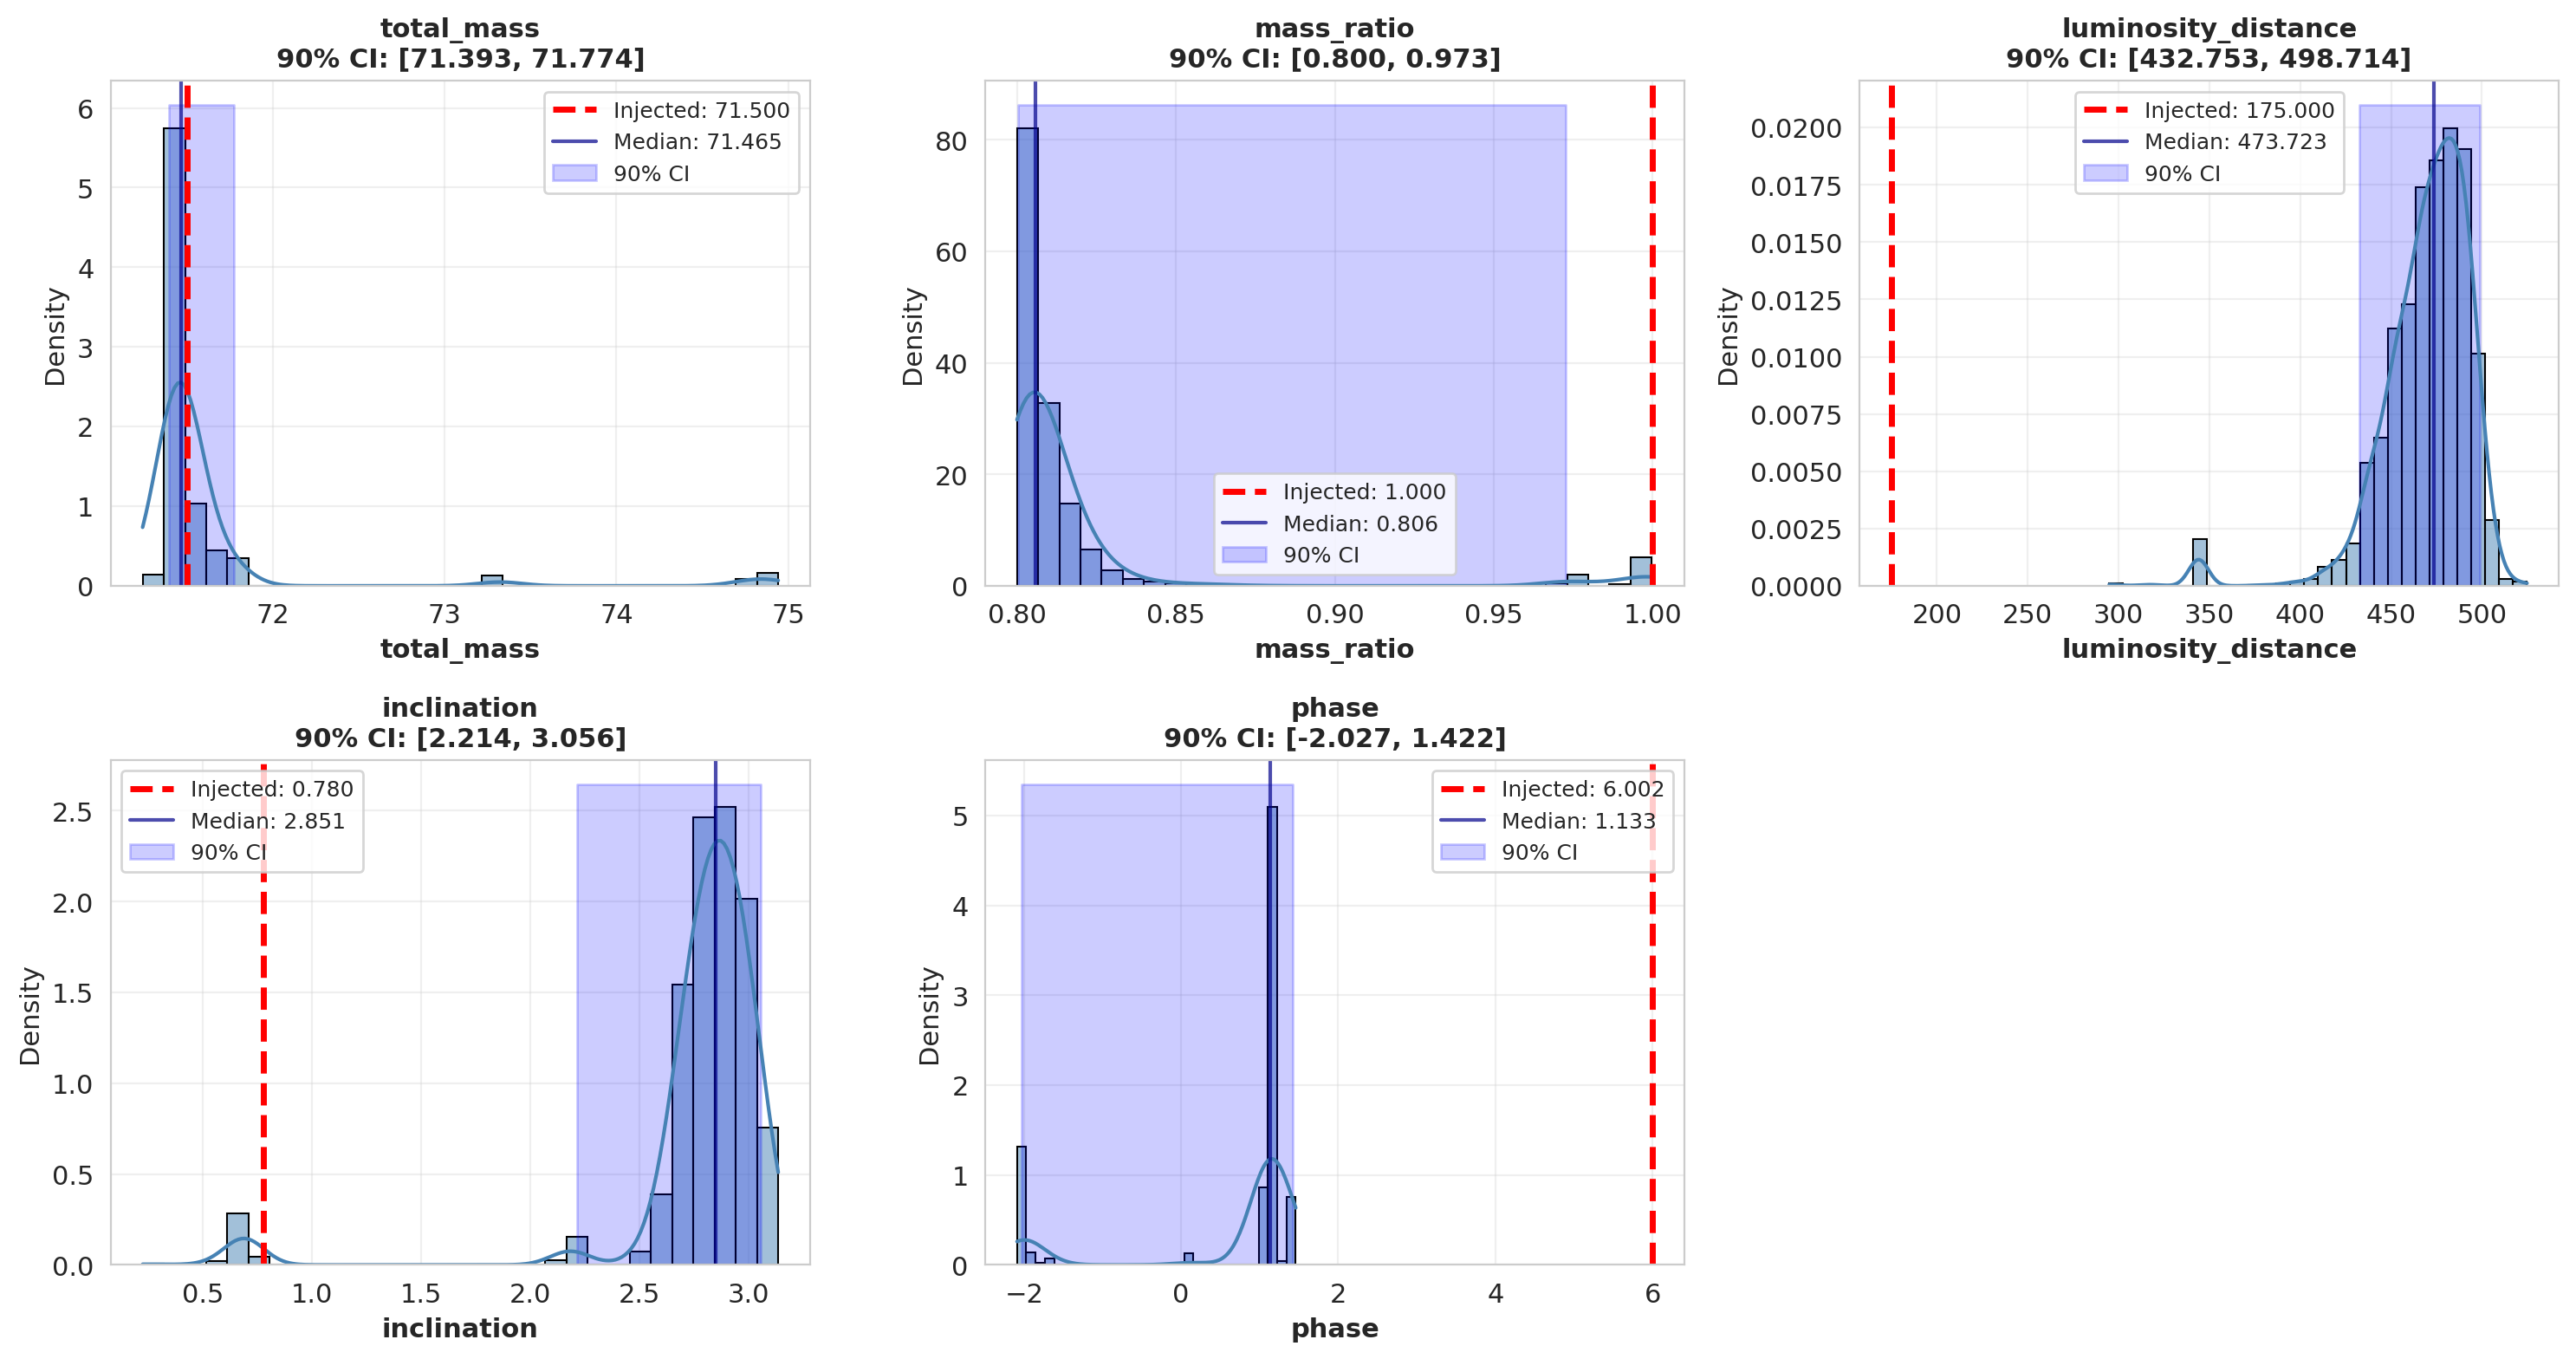

Saved: output/posterior_1d.png


In [37]:
# Plot 1D posteriors with injected values (seaborn style)
n_params = len(param_names)
n_cols = 3
n_rows = int(np.ceil(n_params / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()

for idx, param in enumerate(param_names):
    ax = axes[idx]
    
    # KDE plot with histogram
    sns.histplot(df[param], bins=30, kde=True, ax=ax, stat='density', color='steelblue', edgecolor='black')
    
    # Injected value
    if param in ref_params and not pd.isna(ref_params[param]):
        injected_val = ref_params[param]
        ax.axvline(injected_val, color='red', ls='--', lw=2.5, label=f'Injected: {injected_val:.3f}')
    
    # Posterior statistics
    median = np.median(df[param])
    lower = np.percentile(df[param], 5)
    upper = np.percentile(df[param], 95)
    
    ax.axvline(median, color='darkblue', ls='-', lw=1.5, alpha=0.7, label=f'Median: {median:.3f}')
    ax.fill_betweenx([0, ax.get_ylim()[1]], lower, upper, alpha=0.2, color='blue', label='90% CI')
    
    ax.set_xlabel(param, fontsize=11, weight='bold')
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'{param}\n90% CI: [{lower:.3f}, {upper:.3f}]', fontsize=11, weight='bold')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9, loc='best')

# Hide unused subplots
for idx in range(n_params, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('output/posterior_1d.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: output/posterior_1d.png")

## Corner Plot

Install corner if needed: `pip install corner`

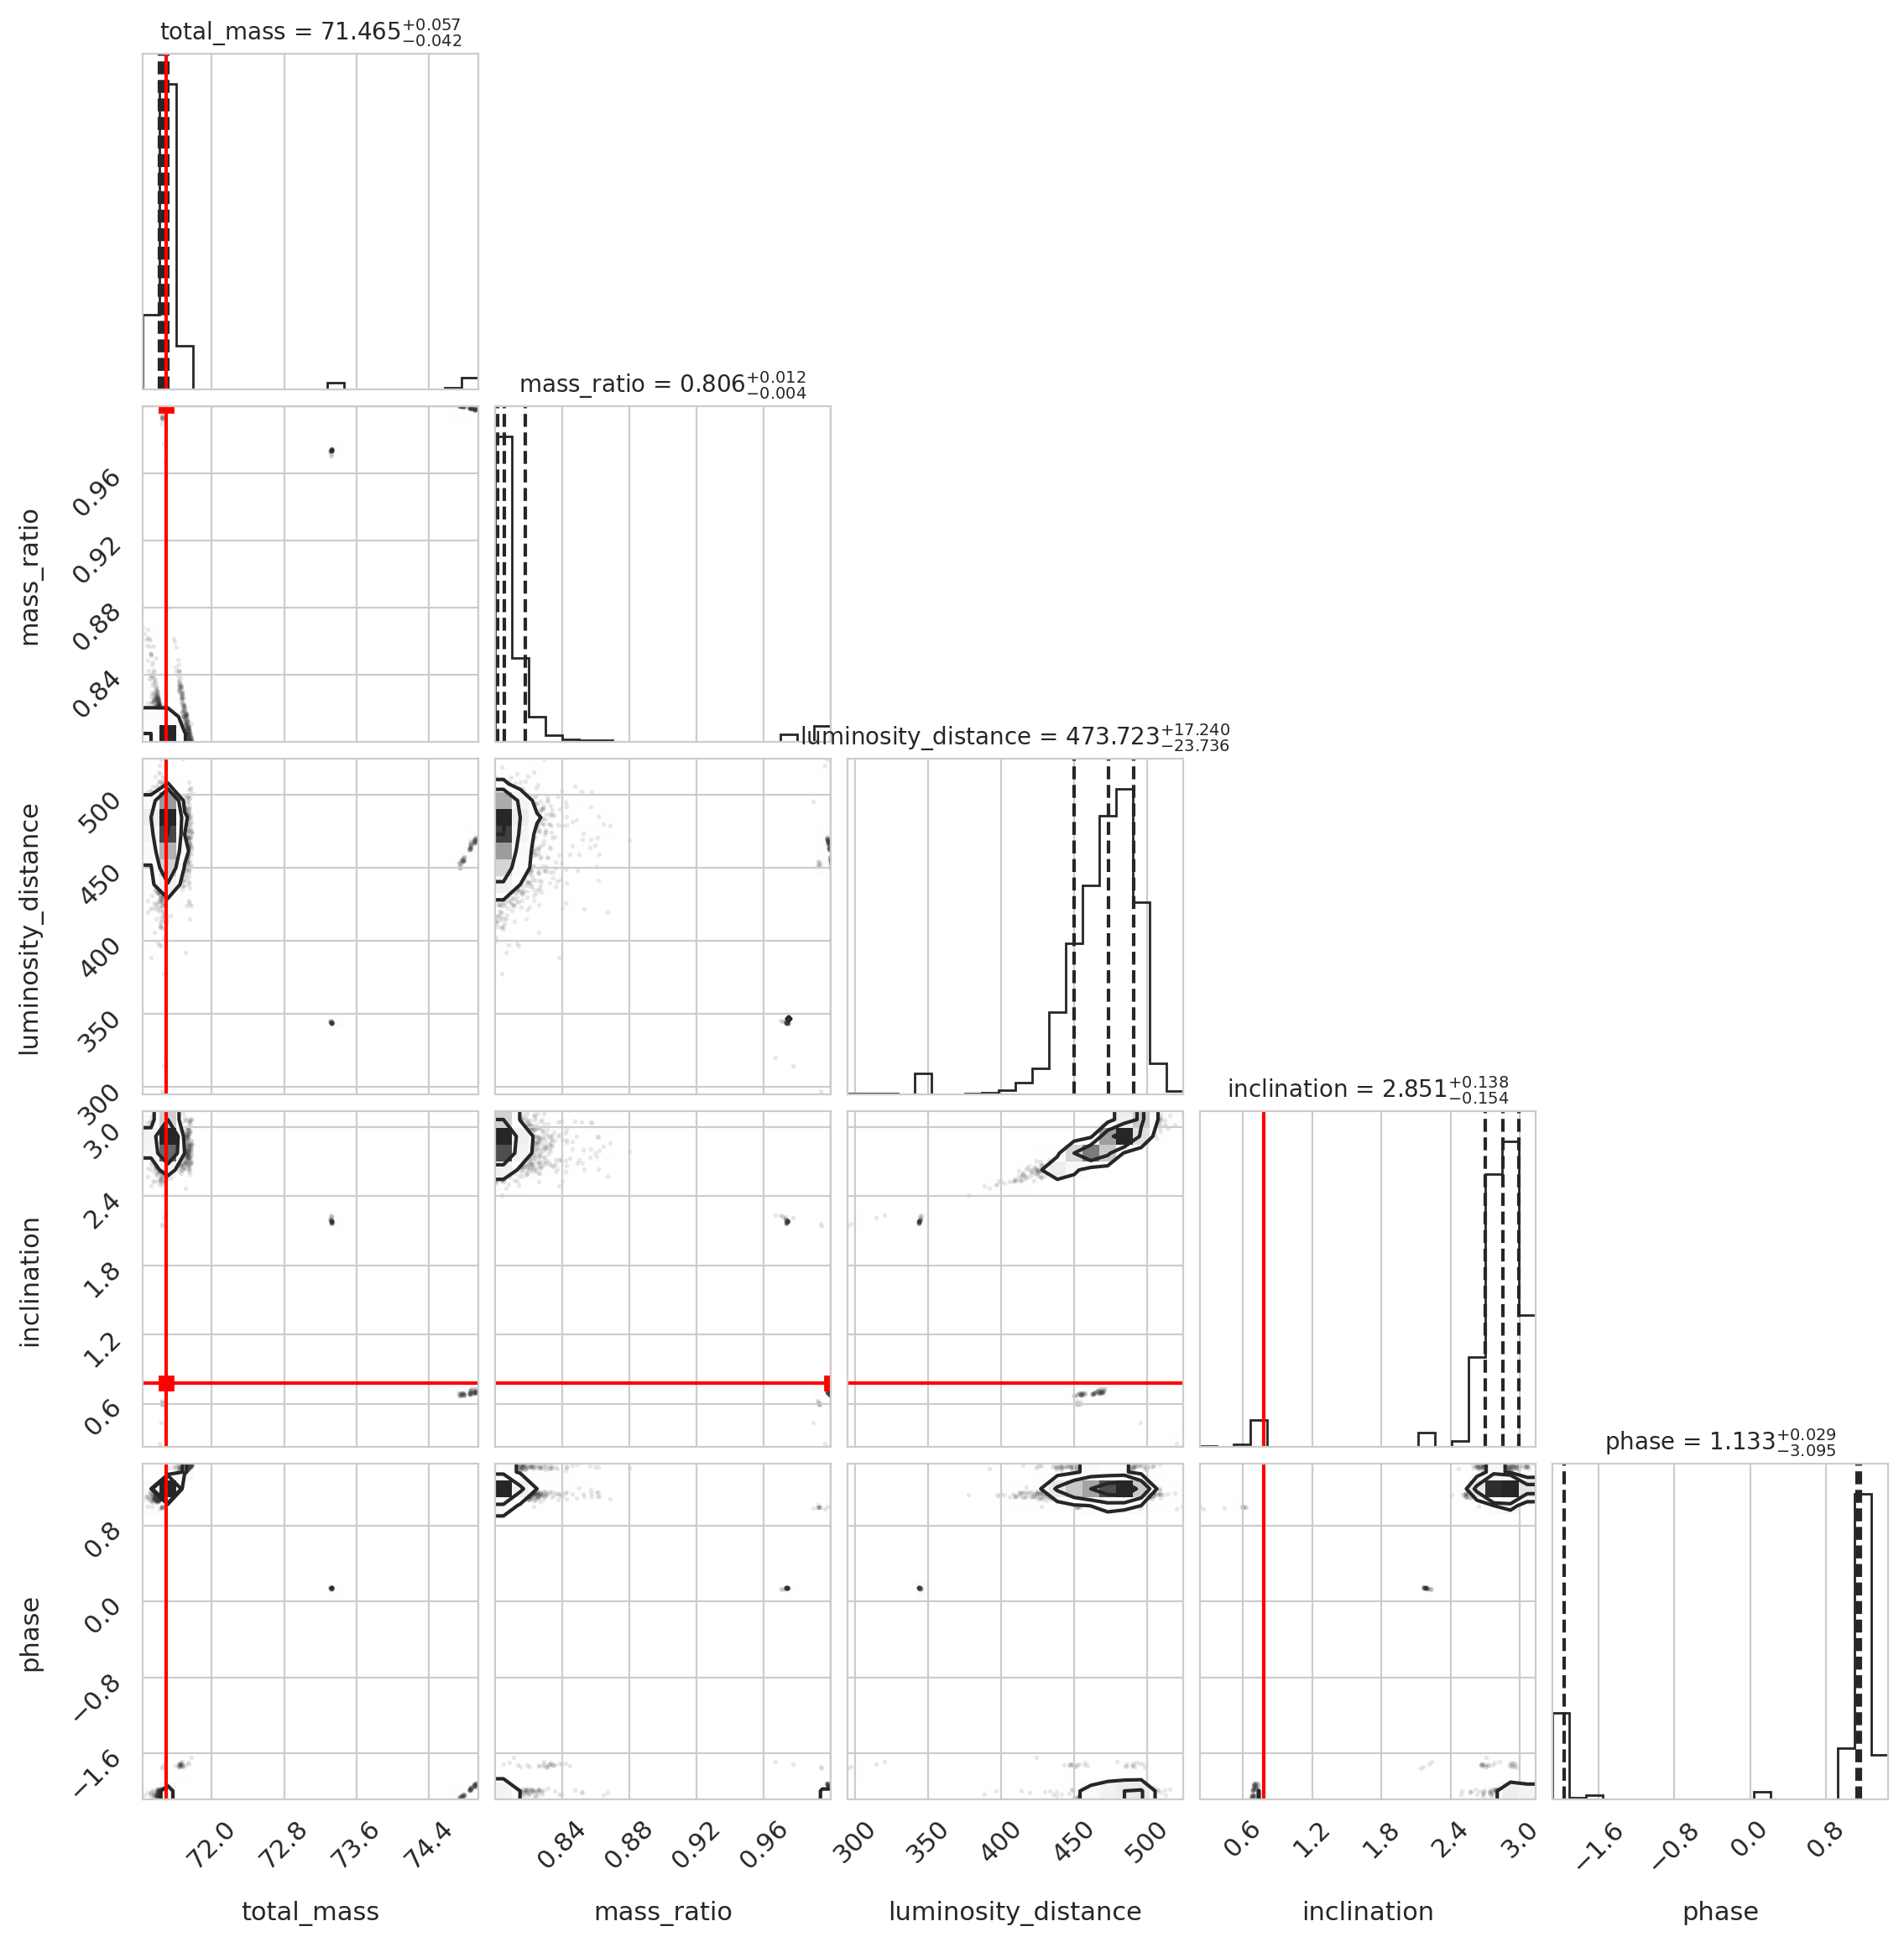

Saved: output/corner_plot.png


In [38]:
import corner

# Create corner plot with KDE contours
truths = [ref_params.get(p, None) for p in param_names if p in ref_params and not pd.isna(ref_params[p])]

fig = corner.corner(
    df[param_names],
    labels=param_names,
    truths=truths if len(truths) == len(param_names) else None,
    truth_color='red',
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_fmt='.3f',
    title_kwargs={"fontsize": 10},
    labelsize=10,
    figsize=(3*len(param_names), 3*len(param_names))
)

plt.savefig('output/corner_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: output/corner_plot.png")

## Compare to Injected Values

In [39]:
# Calculate recovery statistics with better formatting
print("\n" + "=" * 80)
print("PARAMETER RECOVERY ANALYSIS")
print("=" * 80)

recovery_data = []
for param in param_names:
    if param not in ref_params or pd.isna(ref_params[param]):
        continue
    
    true_val = ref_params[param]
    median_val = np.median(df[param])
    std_val = np.std(df[param])
    lower_90 = np.percentile(df[param], 5)
    upper_90 = np.percentile(df[param], 95)
    
    # Check if true value is in 90% CI
    in_ci = lower_90 <= true_val <= upper_90
    
    # Calculate bias and relative error
    bias = median_val - true_val
    rel_error = 100 * bias / true_val if true_val != 0 else np.inf
    
    print(f"\n{param.upper()}")
    print("-" * 80)
    print(f"  Injected value:     {true_val:12.4f}")
    print(f"  Recovered median:   {median_val:12.4f} ± {std_val:.4f}")
    print(f"  90% Credible Int.:  [{lower_90:12.4f}, {upper_90:12.4f}]")
    print(f"  Truth in CI:        {'✓ YES' if in_ci else '✗ NO'}")
    print(f"  Bias:               {bias:+12.4f} ({rel_error:+.2f}%)")
    
    recovery_data.append({
        'Parameter': param,
        'Injected': true_val,
        'Median': median_val,
        'Std': std_val,
        'Lower_90': lower_90,
        'Upper_90': upper_90,
        'In_CI': in_ci,
        'Bias': bias,
        'Rel_Error_%': rel_error
    })

print("\n" + "=" * 80)

# Save recovery statistics
recovery_df = pd.DataFrame(recovery_data)
recovery_df.to_csv('output/recovery_statistics.csv', index=False)
print("\nSaved recovery statistics to: output/recovery_statistics.csv")


PARAMETER RECOVERY ANALYSIS

TOTAL_MASS
--------------------------------------------------------------------------------
  Injected value:          71.5000
  Recovered median:        71.4655 ± 0.6287
  90% Credible Int.:  [     71.3930,      71.7744]
  Truth in CI:        ✓ YES
  Bias:                    -0.0345 (-0.05%)

MASS_RATIO
--------------------------------------------------------------------------------
  Injected value:           1.0000
  Recovered median:         0.8057 ± 0.0416
  90% Credible Int.:  [      0.8003,       0.9727]
  Truth in CI:        ✗ NO
  Bias:                    -0.1943 (-19.43%)

LUMINOSITY_DISTANCE
--------------------------------------------------------------------------------
  Injected value:         175.0000
  Recovered median:       473.7230 ± 25.9871
  90% Credible Int.:  [    432.7530,     498.7141]
  Truth in CI:        ✗ NO
  Bias:                  +298.7230 (+170.70%)

INCLINATION
--------------------------------------------------------------

## Save Summary Statistics

In [40]:
# Save all summary statistics to files
print("\nSaving summary statistics...")

# Posterior summary
posterior_summary = df[param_names].describe()
posterior_summary.to_csv('output/posterior_summary.csv')

# Full posterior data
df.to_csv('output/posterior_samples_full.csv', index=False)

print("  ✓ Saved: output/posterior_summary.csv")
print("  ✓ Saved: output/recovery_statistics.csv")
print("  ✓ Saved: output/posterior_samples_full.csv")
print("  ✓ Saved: output/posterior_1d.png")
print("  ✓ Saved: output/corner_plot.png")
print("\nAnalysis complete!")


Saving summary statistics...
  ✓ Saved: output/posterior_summary.csv
  ✓ Saved: output/recovery_statistics.csv
  ✓ Saved: output/posterior_samples_full.csv
  ✓ Saved: output/posterior_1d.png
  ✓ Saved: output/corner_plot.png

Analysis complete!
